In [2]:
import pandas as pd
import json

with open("../models/lstm_result.json") as f:
    lstm_results = json.load(f)

with open("../models/prophet_results.json") as f:
    prophet_results = json.load(f)

with open("../models/arima_model_results.json") as f:
    arima_results = json.load(f)

print(arima_results)
print(prophet_results)
print(lstm_results)

{'ARIMA(0,1,0)': 31.530821250005292, 'ARIMA(1, 1, 1)': 34.16438380689604, 'ARIMA(2, 1, 2)': 31.423387441006582}
{'Prophet RMSE': 101.1961359247235}
{'LSTM RMSE': 22.158044516743036}


In [4]:
results_summary = {
    "ARIMA(2,1,2)": arima_results["ARIMA(2, 1, 2)"],
    "Prophet": prophet_results["Prophet RMSE"],
    "LSTM": lstm_results["LSTM RMSE"]
}

In [6]:
results_df = pd.DataFrame.from_dict(results_summary, orient='index', columns=['RMSE'])
results_df = results_df.sort_values(by='RMSE')
results_df

,RMSE
LSTM,22.158045
"ARIMA(2,1,2)",31.423387
Prophet,101.196136


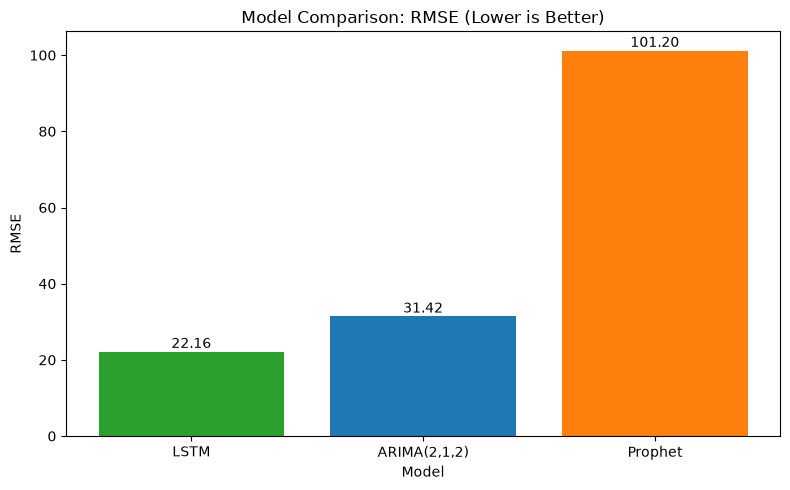

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
bars = plt.bar(results_df.index, results_df['RMSE'], color=['#2ca02c', '#1f77b4', '#ff7f0e'])

plt.title("Model Comparison: RMSE (Lower is Better)")
plt.ylabel("RMSE")
plt.xlabel("Model")

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1,
              f"{height:.2f}", ha='center', fontsize=10)

plt.tight_layout()
plt.savefig("../assets/rmse_comparison.png", dpi=150)
plt.show()